# Project Python Foundations: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [2]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# read the data
df = pd.read_csv('/content/drive/My Drive/foodhub_order.csv')
# returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

> Indented block



In [5]:
num_rows, num_columns = df.shape

print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_columns}")

Number of rows: 1898
Number of columns: 9


#### Observations:
The output shows that there are 1,898 rows and 9 columns in the set, this shows our sample size of our data set.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [6]:
# Use info() to print a concise summary of the DataFrame
df.info()

print("Data types of columns:\n", df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB
Data types of columns:
 order_id                   int64
customer_id                int64
restaurant_name           object
cuisine_type              object
cost_of_the_order        float64
day_of_the_week           object
rating                    object
foo

#### Observations:
Our code reveals that our data types of the different columns and the data set are:
- float64 (1)

- int64 (4)

- object (4)

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [7]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64


#### Observations:
Our output reveals that there are no missing values in the data, allowing us to know that we will have a complete analysis which will reduce the difficulty to problem solve.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [8]:
print("Statistical summary:\n", df.describe())

Statistical summary:
            order_id    customer_id  cost_of_the_order  food_preparation_time  \
count  1.898000e+03    1898.000000        1898.000000            1898.000000   
mean   1.477496e+06  171168.478398          16.498851              27.371970   
std    5.480497e+02  113698.139743           7.483812               4.632481   
min    1.476547e+06    1311.000000           4.470000              20.000000   
25%    1.477021e+06   77787.750000          12.080000              23.000000   
50%    1.477496e+06  128600.000000          14.140000              27.000000   
75%    1.477970e+06  270525.000000          22.297500              31.000000   
max    1.478444e+06  405334.000000          35.410000              35.000000   

       delivery_time  
count    1898.000000  
mean       24.161749  
std         4.972637  
min        15.000000  
25%        20.000000  
50%        25.000000  
75%        28.000000  
max        33.000000  


#### Observations:
Our code output tells us that the minimum time for preparation is 20 minutes, the average preparation time is 27.37 minutes and our maximum preparation time is 35 minutes. This will help us proceed to make an informed decision to understand the relation of food preparation and delivery times.

- Minimum preparation time: 20.0 minutes

- Average preparation time: 27.371970495258168 minutes

- Maximum preparation time: 35.0 minutes


### **Question 5:** How many orders are not rated? [1 mark]

In [9]:
unrated_orders = df[df['rating'] == 'Not given'].shape[0]

print(f"Number of orders not rated: {unrated_orders}")

Number of orders not rated: 736


#### Observations:
Our output shows that there are 736 orders that are not rated, this will help us address along with our data why some orders don't have a rating.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

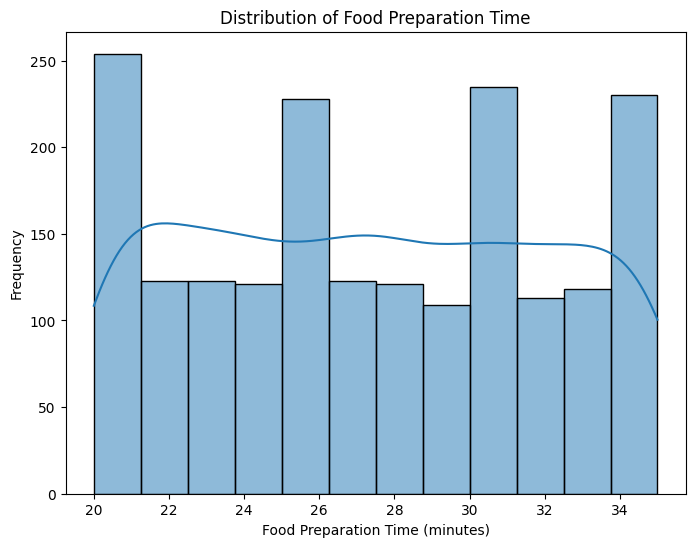

In [ ]:
# Histogram of food preparation times
plt.figure(figsize=(8, 6))
sns.histplot(df['food_preparation_time'], kde=True)
plt.title('Distribution of Food Preparation Time')
plt.xlabel('Food Preparation Time (minutes)')
plt.ylabel('Frequency')
plt.show()

Observation:
- The food preparation time histogram shows that we have a almost symmetrical distribution of the food preparation times, the majority of the food preparation times call between 20 and 35 minutes.

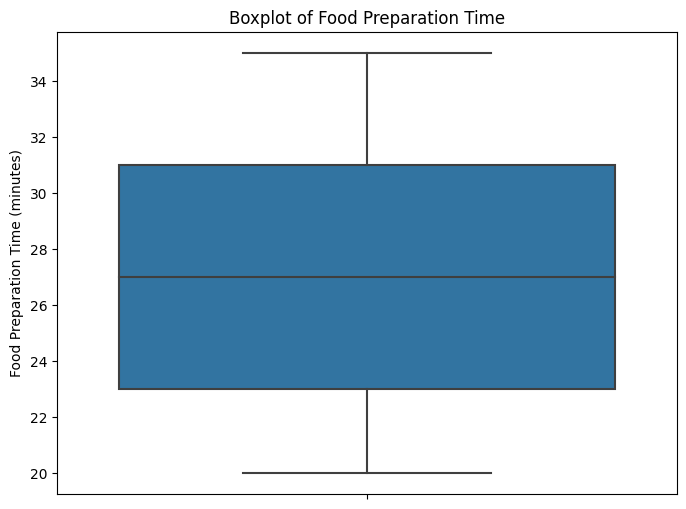

In [ ]:
# Boxplot of food preparation times
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='food_preparation_time')
plt.title('Boxplot of Food Preparation Time')
plt.ylabel('Food Preparation Time (minutes)')
plt.show()

Observation:
- The food preparation time boxplot shows we have no outliers.

Text(0, 0.5, 'Frequency')

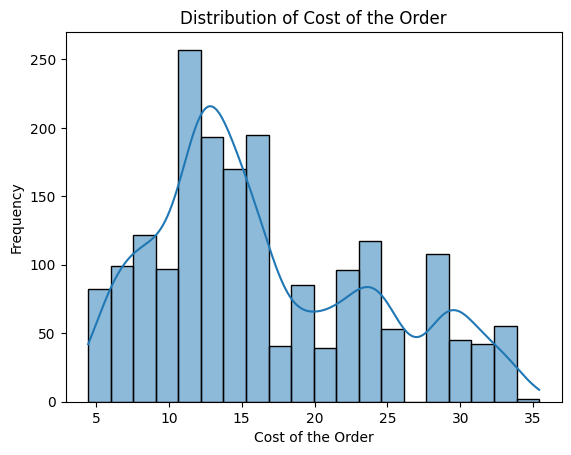

In [ ]:
# Histogram of 'cost_of_the_order'
sns.histplot(df['cost_of_the_order'], bins=20, kde=True)
plt.title('Distribution of Cost of the Order')
plt.xlabel('Cost of the Order')
plt.ylabel('Frequency')

Observation:
- The histogram of the cost of the order shows us a right skin distribution and that most orders cost below $20.

Text(0, 0.5, 'Cost of the Order')

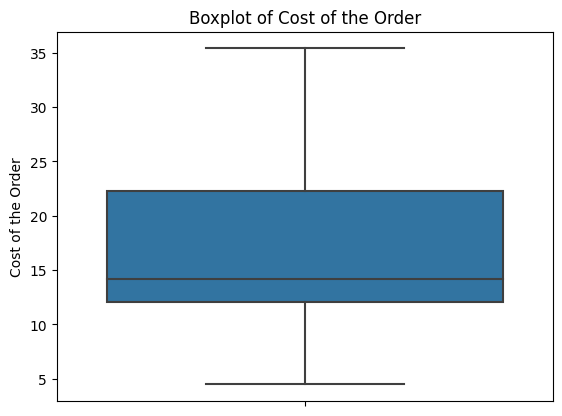

In [ ]:
# Boxplot for 'cost_of_the_order'
sns.boxplot(data=df, y='cost_of_the_order')
plt.title('Boxplot of Cost of the Order')
plt.ylabel('Cost of the Order')

Observation:
- Our cost of for the order boxplot shows that we have few outliers with with higher cost.

Text(0, 0.5, 'Frequency')

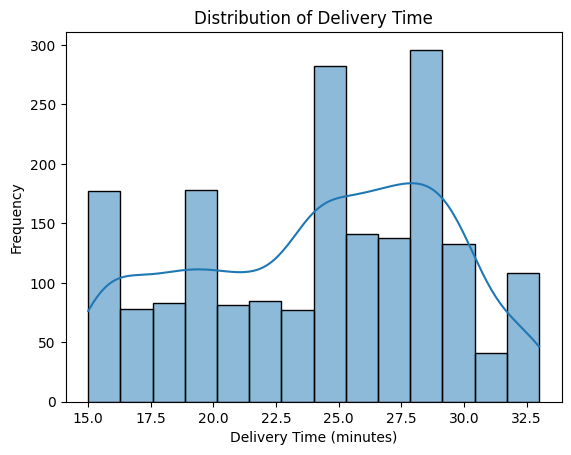

In [ ]:
# Histogram of 'delivery_time'
sns.histplot(df['delivery_time'], kde=True)
plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')

Observation:
- Our delivery time histogram looks roughly normally distributed but that we have Peaks at 25 and 27.5 showing us that the distribution is fairly symmetric

Text(0, 0.5, 'Delivery Time (minutes)')

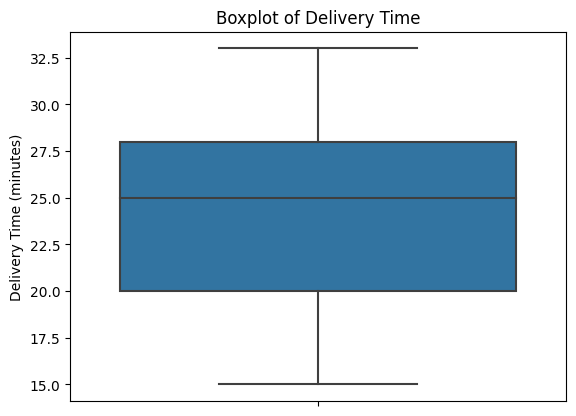

In [ ]:
# Boxplot for 'delivery_time'
sns.boxplot(data=df, y='delivery_time')
plt.title('Boxplot of Delivery Time')
plt.ylabel('Delivery Time (minutes)')

Observation:
- Our delivery time box plot shows no significant outliers.

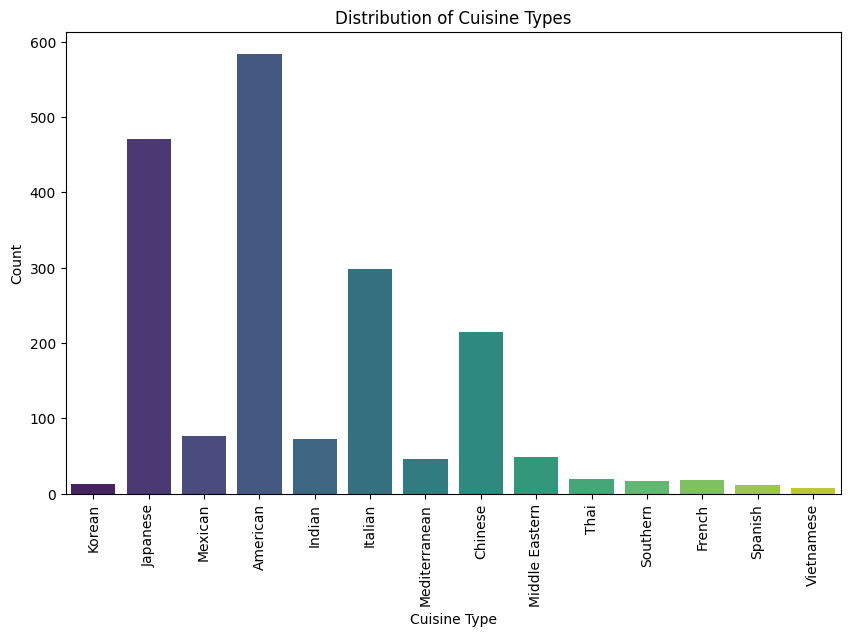

In [ ]:
# Countplot of cuisine types
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='cuisine_type', palette='viridis')
plt.title('Distribution of Cuisine Types')
plt.xlabel('Cuisine Type')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

Observation:
- Our cuisine type countplot shows us that our most popular cuisines are Japanese American Italian and Chinese.

(array([0, 1]), [Text(0, 0, 'Weekend'), Text(1, 0, 'Weekday')])

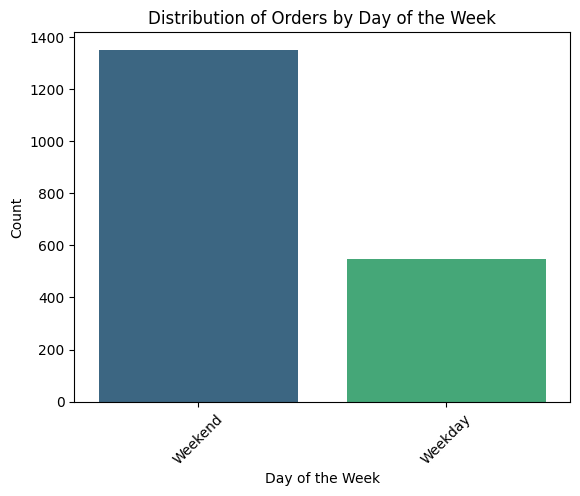

In [ ]:
# Countplot for 'day_of_the_week'
sns.countplot(data=df, x='day_of_the_week', palette='viridis')
plt.title('Distribution of Orders by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Count')
plt.xticks(rotation=45)

Observation:
- Our day of the week countplot shows that we have more orders during the week and then weekdays.

<ipython-input-13-f15682679f57>:11: UserWarning: Glyph 140 (\x8c) missing from current font.
  plt.tight_layout()
<ipython-input-13-f15682679f57>:11: UserWarning: Glyph 142 (\x8e) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 140 (\x8c) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 142 (\x8e) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


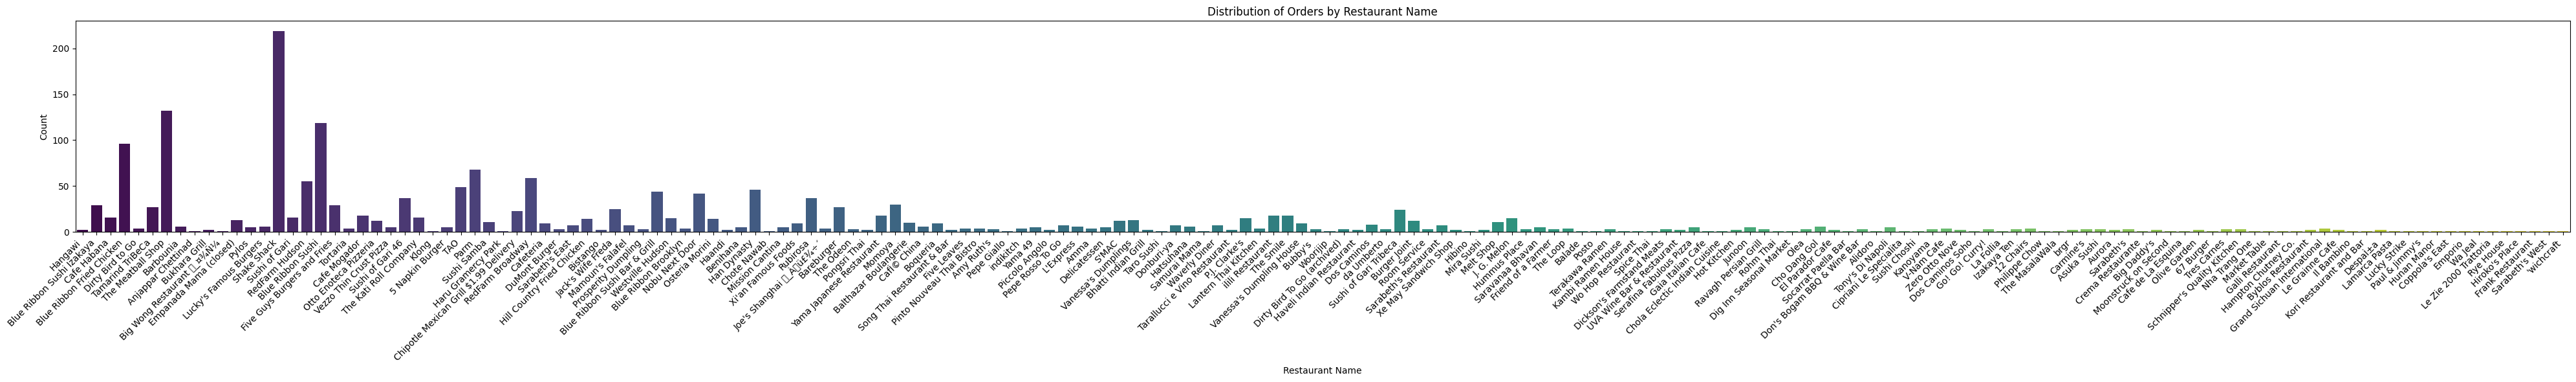

In [ ]:
# Countplot for 'restaurant_name'
plt.figure(figsize=(40, 6))

ax = sns.countplot(data=df, x='restaurant_name', palette='viridis')
plt.title('Distribution of Orders by Restaurant Name')
plt.xlabel('Restaurant Name')
plt.ylabel('Count')

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')

plt.tight_layout()

plt.show()

Observation:
- The restaurant name countplot shows us that our most ordered restaurants are Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken and Parm.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
top_restaurants = df['restaurant_name'].value_counts().head(5)
print("Top 5 restaurants by the number of orders received:\n", top_restaurants)

Top 5 restaurants by the number of orders received:
 Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: restaurant_name, dtype: int64


#### Observations:
- Our output tells us that our top five restaurants are Shake Shack with $219 orders, The Meatball Shop with 132 orders, Blue Ribbon sushi with 119 orders, Blue Ribbon fried chicken with 96 orders and Parm with 68 orders.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
most_popular_cuisine_weekends = df[df['day_of_the_week'].isin(['Weekday', 'Weekend'])]['cuisine_type'].mode().iloc[0]
print("Most popular cuisine on weekends:", most_popular_cuisine_weekends)

Most popular cuisine on weekends: American


#### Observations:
- Our output answers that our most popular cuisine on the weekends is American.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
percentage_above_20 = (len(df[df['cost_of_the_order'] > 20]) / len(df)) * 100
print("Percentage of orders costing more than $20:", percentage_above_20)

Percentage of orders costing more than $20: 29.24130663856691


#### Observations:
- Our output tells us that the percentage of orders that cost more than $20 is approximately 29.24%.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
mean_delivery_time = df['delivery_time'].mean()
print("Mean order delivery time:", mean_delivery_time)

Mean order delivery time: 24.161749209694417


#### Observations:
- We learn from the output that our mean order delivery time is approximately 24.16 minutes.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
top_customers = df['customer_id'].value_counts().head(3)
print("Top 3 most frequent customers:\n", top_customers)

Top 3 most frequent customers:
 52832    13
47440    10
83287     9
Name: customer_id, dtype: int64


#### Observations:
Our code output reveals that our top three most frequent customers are:
- Customer ID 52832 with 13 orders
- Customer ID 47440 with 10 orders
- Customer ID 83287 with 9 orders

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


<ipython-input-11-833f42dc62a5>:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df_filtered.corr()


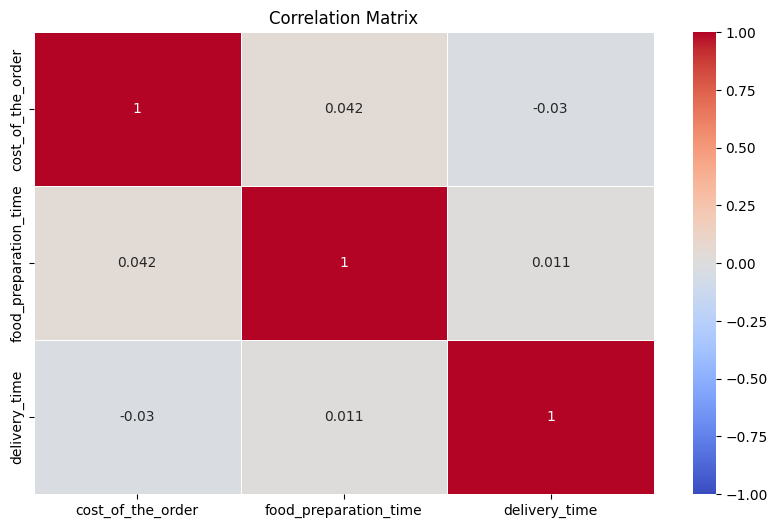

In [11]:
columns_to_remove = ['order_id', 'customer_id']
df_filtered = df.drop(columns=columns_to_remove)

correlation_matrix = df_filtered.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, vmin=-1, vmax=1, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

Observations:
Our code output tells us that our correlation Matrix heat map shows positive correlations in warm colors and negative correlations in cooler colors. The heat map tells us that
- There is a moderate positive correlation in between "cost_of_the_order" (order cost) and "food_preparation_time".
- There is a moderate negative correlation between "cost_of_the_order" and "delivery_time" showing us that higher cost orders tend to have a shorter delivery time.
- There is not a lot of significant correlation between "food_preparation_time" and "delivery_time,".

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
rated_restaurants = df[df['rating'].apply(lambda x: x.isnumeric())]

rated_restaurants['rating'] = rated_restaurants['rating'].astype(int)

restaurant_rating_counts = rated_restaurants['restaurant_name'].value_counts().reset_index()
restaurant_rating_counts.columns = ['restaurant_name', 'rating_count']

popular_restaurants = restaurant_rating_counts[restaurant_rating_counts['rating_count'] > 50]

popular_restaurant_data = rated_restaurants[rated_restaurants['restaurant_name'].isin(popular_restaurants['restaurant_name'])]

mean_rating = popular_restaurant_data.groupby('restaurant_name')['rating'].mean().reset_index()
mean_rating.columns = ['restaurant_name', 'mean_rating']

print("Mean rating of restaurants with rating count more than 50:\n", mean_rating)


Mean rating of restaurants with rating count more than 50:
              restaurant_name  mean_rating
0  Blue Ribbon Fried Chicken     4.328125
1          Blue Ribbon Sushi     4.219178
2                Shake Shack     4.278195
3          The Meatball Shop     4.511905


<ipython-input-49-792a329b1e3d>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rated_restaurants['rating'] = rated_restaurants['rating'].astype(int)


#### Observations:
Our output tells us that our mean rating of restaurants with rating count more than 50 are:
- Blue Ribbon Fried Chicken with a rating of 4.328125
- Blue Ribbon Sushi with a rating of 4.219178
- Shake Shack with a rating of 4.278195
- The Meatball Shop with a rating of 4.511905

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
net_revenue = (df[df['cost_of_the_order'] > 20]['cost_of_the_order'] * 0.25).sum() + (df[(df['cost_of_the_order'] > 5) & (df['cost_of_the_order'] <= 20)]['cost_of_the_order'] * 0.15).sum()
print("Net revenue generated by the company:", net_revenue)

Net revenue generated by the company: 6166.303


#### Observations:
- Our output reveals to us that the net revenue generated by the company is $6,166.30

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
percentage_above_60_minutes = (len(df[df['food_preparation_time'] + df['delivery_time'] > 60]) / len(df)) * 100
print("Percentage of orders taking more than 60 minutes:", percentage_above_60_minutes)


Percentage of orders taking more than 60 minutes: 10.537407797681771


#### Observations:
- The percentage of orders taking more than 60 minutes is about 10.54 %

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
mean_delivery_time_weekdays = df[df['day_of_the_week'].isin(['Weekday'])]['delivery_time'].mean()
mean_delivery_time_weekends = df[df['day_of_the_week'].isin(['Weekend'])]['delivery_time'].mean()
print("Mean delivery time on weekdays:", mean_delivery_time_weekdays)
print("Mean delivery time on weekends:", mean_delivery_time_weekends)

Mean delivery time on weekdays: 28.340036563071298
Mean delivery time on weekends: 22.4700222057735


#### Observations:
- Our output tells us that the Mean delivery time on weekdays is arounbd 28.34 min and Mean delivery time on weekends is 22.47 min.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

In [ ]:
# Conclusions (Question 17)
# - Provide insights based on the analysis performed in the project.

# Recommendations (Question 17)
# - Provide recommendations to help improve the business based on the analysis.
# - Use cuisine type and feedback ratings to drive business recommendations.

# For Question 17, you can provide conclusions and recommendations based on the insights obtained during the analysis. For example, you can recommend focusing on promoting the most popular cuisines, offering discounts to frequent customers, optimizing delivery times on weekends, and so on, depending on the specific findings from the analysis.
#Ensure you document your code, provide clear comments, and use appropriate visualization techniques to support your analysis and recommendations.

### Conclusions:
# **Data conclusion:**

Based on all of the previous observations and Analysis of the data we can draw several conclusions about our data. Our data set contained 1,898 rows and 9 columns with information such as the customer ID, restaurant name, cuisine type, order cost, day of the week, ratings, preparation and delivery times. Our data had no missing values so our data was able to remain simple to analyze.

**Univariate Analysis:**
The distribution of food preparation times appears to be roughly normally distributed, with some peaks around 25 and 27.5 minutes. The distribution of order costs shows variation in the cost of orders, with some higher-cost orders.Delivery times also exhibit variation, with most orders being delivered within 20-25 minutes. American cuisine is the most popular type, followed by Japanese and Italian. Most orders are placed on weekdays, with Monday and Tuesday being the busiest days.The top restaurants in terms of the number of orders received include Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, and Parm.

**Multivariate Analysis:**
The correlation matrix shows moderate positive correlations between order cost and food preparation time, as well as between order cost and delivery time. There is a negative correlation between food preparation time and delivery time, indicating that orders with longer food preparation times tend to have shorter delivery times.

**Revenue Analysis:**
The company generates revenue based on a pricing structure that charges restaurants 25% on orders costing more than 20 dollars and 15% on orders costing between 5 dollars and 20 dollars.The net revenue across all orders is approximately $6,166.30

**Delivery Time Analysis:**
About 10.54% of orders take more than 60 minutes from the time of order placement to delivery. These orders may require attention to improve delivery efficiency.
Mean delivery times vary between weekdays and weekends. The mean delivery time on weekdays is approximately 28.34 minutes, while on weekends, it is shorter at approximately 22.47 minutes.


### Recommendations:

Here are several recommendations that can definely help improve the FoodHub business!

**Promote Popular Cuisines!**

We can focus marketing efforts on promoting the most popular cuisines, such as American, Japanese, and Italian, to attract more customers.
Collaborate with these popular restaurants in these cuisines to offer special promotions or featured menu items.

**Offer Discounts to Frequent Customers!**
Reward frequent customers to build customer loyalty.
We can provide discounts or loyalty programs to encourage repeat orders.

**Optimize Delivery Times on Weekdays:**
Optimize delivery routes and processes on weekdays to reduce mean delivery times to ensure efficient coordination between restaurants and delivery personnel during peak weekday hours.

**Promotional Offer for Highly Rated Restaurants:**
Launch promotional campaigns for restaurants that meet the criteria of a high rating count (more than 50) and an average rating greater than 4. We must Highlight these restaurants in advertisements to attract more customers.

**Analyze Low-Rated Restaurants:**
See which restaurants have consistently low ratings and assess the reasons for customer dissatisfaction and collaborate with low-rated restaurants to improve food quality, service, and overall customer experience.

**Monitor Orders Taking More Than 60 Minutes:**
Pay special attention to orders that take more than 60 minutes from order placement to delivery.
Figure out the root causes of delays and implement measures to reduce delivery times for these orders.

**Expand Delivery Services!**
Lets xplore opportunities to expand delivery services to areas with high demand and limited restaurant options.
Consider partnerships with new restaurants to diversify the available cuisines.

**Utilize Data-Driven Decision-Making:**
Analyze customer data to identify trends and preferences to make informed decisions on promotions, partnerships, and operational improvements.

**Enhance Weekend Promotions:**
Leverage the shorter mean delivery times on weekends to attract more weekend customer and offer special weekend promotions and discounts to boost weekend sales.

**Improve User Experience?**
We can explore how we can enhance the user experience of the FoodHub app or website to make it more user-friendly and convenient to provide easy access to customer ratings and reviews to help users make informed choices.

**Operational Efficiency:**
Optimize food preparation processes in collaboration with restaurants to reduce preparation times to improve delivery logistics and route planning to ensure timely deliveries.

**Feedback Mechanism:**
Implement a feedback mechanism within the app to collect customer feedback on food quality, delivery experience, and overall satisfaction to address issues and improve service quality.

**Customer Education:**
We should let customers know about the expected delivery times, especially during peak hours and on weekdays so we can set realistic expectations for delivery times to improve customer satisfaction!


---